In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image as grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image could not be loaded")
else:
    print("Image loaded successfully!")
    print("Image size:", img.shape)

Saving input.webp to input.webp
Image loaded successfully!
Image size: (534, 800)


In [3]:
# Enter filter size
kernel_size = int(input("Enter filter size (odd number, e.g. 3, 5, 7): "))

# Check if kernel size is odd
if kernel_size % 2 == 0:
    print("Please enter an odd number.")
else:
    print("Filter size:", kernel_size)

# Select padding method
print("\nPadding methods:")
print("1. Zero padding")
print("2. Replication padding")

padding_choice = int(input("Enter your choice (1 or 2): "))

if padding_choice == 1:
    padding_mode = "zero"
elif padding_choice == 2:
    padding_mode = "replicate"
else:
    print("Invalid choice")

Enter filter size (odd number, e.g. 3, 5, 7): 3
Filter size: 3

Padding methods:
1. Zero padding
2. Replication padding
Enter your choice (1 or 2): 2


In [4]:
def pad_image(img, pad, mode):

    if mode == "zero":
        padded = np.pad(
            img,
            ((pad, pad), (pad, pad)),
            mode='constant',
            constant_values=0
        )

    elif mode == "replicate":
        padded = np.pad(
            img,
            ((pad, pad), (pad, pad)),
            mode='edge'
        )

    return padded

In [5]:
def averaging_filter(img, kernel_size, padding_mode):

    pad = kernel_size // 2

    padded = pad_image(img, pad, padding_mode)

    output = np.zeros_like(img, dtype=np.float64)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ]

            output[i, j] = np.mean(window)

    return np.uint8(output)

In [6]:
def weighted_filter(img, kernel_size, padding_mode):

    pad = kernel_size // 2

    # Create coordinates
    x = np.arange(-pad, pad + 1)
    y = np.arange(-pad, pad + 1)

    X, Y = np.meshgrid(x, y)

    # h(x,y) = max(|x|, |y|)
    kernel = np.maximum(np.abs(X), np.abs(Y)).astype(float)

    # Avoid zero weight at center
    kernel[pad, pad] = 1

    # Normalize kernel
    kernel = kernel / np.sum(kernel)

    padded = pad_image(img, pad, padding_mode)

    output = np.zeros_like(img, dtype=np.float64)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ]

            output[i, j] = np.sum(window * kernel)

    return np.uint8(output)

In [7]:
sigma = float(input("Enter Gaussian sigma (e.g. 1.0): "))

Enter Gaussian sigma (e.g. 1.0): 1


In [8]:
def gaussian_filter(img, kernel_size, sigma, padding_mode):

    pad = kernel_size // 2

    # Coordinates
    x = np.arange(-pad, pad + 1)
    y = np.arange(-pad, pad + 1)

    X, Y = np.meshgrid(x, y)

    # Gaussian formula
    kernel = np.exp(
        -(X**2 + Y**2) / (2 * sigma**2)
    )

    # Normalize
    kernel = kernel / np.sum(kernel)

    padded = pad_image(img, pad, padding_mode)

    output = np.zeros_like(img, dtype=np.float64)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            window = padded[
                i:i+kernel_size,
                j:j+kernel_size
            ]

            output[i, j] = np.sum(window * kernel)

    return np.uint8(output)

In [9]:
avg_img = averaging_filter(
    img,
    kernel_size,
    padding_mode
)

weighted_img = weighted_filter(
    img,
    kernel_size,
    padding_mode
)

gaussian_img = gaussian_filter(
    img,
    kernel_size,
    sigma,
    padding_mode
)

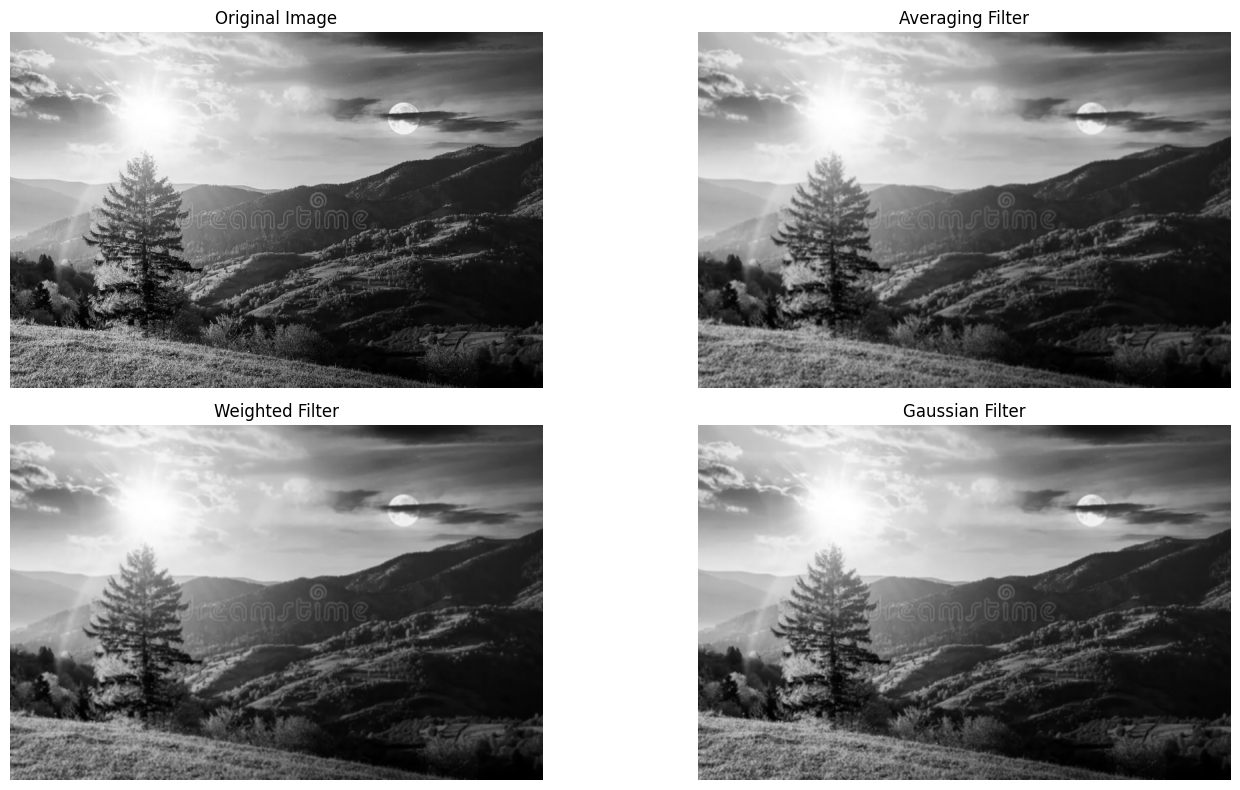

In [10]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(avg_img, cmap='gray')
plt.title("Averaging Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(weighted_img, cmap='gray')
plt.title("Weighted Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_img, cmap='gray')
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()